In [ ]:
!pip install rasterio 
!pip install fiona
!pip install rasterstats
!pip install raster4ml
!pip install sklearn
!pip install shapely

In [ ]:
import numpy as np
import fiona
import rasterio.mask
from matplotlib import pyplot
import pandas as pd
import glob
import os
import rasterio
import raster4ml
from rasterio.crs import CRS
from rasterio.plot import show
from raster4ml.extraction import batch_extract_by_polygons, extract_shape_values, batch_extract_by_non_black_pixels
import os
import gc
import shutil
import csv
import re

os.chdir(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\\')

def create_directory(dir, name):
    # Directory
    directory = name

    # Parent Directory path
    parent_dir = dir

    # Path
    path = os.path.join(parent_dir, directory)

    # Create the directory
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)

In [ ]:
def get_bands(pixel_values):
    bands = dict.fromkeys(['blue', 'green', 'red', 'rede', 'nir'], [])
    bands['blue'] = pixel_values[0]
    bands['green'] = pixel_values[1]
    bands['red'] = pixel_values[2]
    bands['rede'] = pixel_values[3]
    bands['nir'] = pixel_values[4]
    return bands

def generate_indexes_per_batch(dir, profile, bands, segment=None):
    profile.update(
        dtype=rasterio.float32,
        count=1)

    create_directory(dir, "INDEXES")
    with rasterio.open(dir+"/INDEXES/blue.tif", 'w', **profile) as rst:
        rst.write_band(1, bands['blue'].astype('float32'))
        del rst
        gc.collect()

    
    with rasterio.open(dir+"/INDEXES/green.tif", 'w', **profile) as rst:
        rst.write_band(1, bands['green'].astype('float32'))
        del rst
        gc.collect()

    with rasterio.open(dir+"/INDEXES/red.tif", 'w', **profile) as rst:
        rst.write_band(1, bands['red'].astype('float32'))
        del rst
        gc.collect()

    with rasterio.open(dir+"/INDEXES/rede.tif", 'w', **profile) as rst:
        rst.write_band(1, bands['rede'].astype('float32'))
        del rst
        gc.collect()

    with rasterio.open(dir+"/INDEXES/nir.tif", 'w', **profile) as rst:
        rst.write_band(1, bands['nir'].astype('float32'))
        del rst
        gc.collect()

    NDVI = (bands['nir'] - bands['red']) / (bands['nir'] + bands['red'])
    with rasterio.open(dir+"/INDEXES/NDVI.tif", 'w', **profile) as rst:
        rst.write_band(1, NDVI.astype('float32'))
        del rst
        gc.collect()

    GNDVI = (bands['nir']-bands['green'])/(bands['nir']+bands['green'])
    with rasterio.open(dir+"/INDEXES/GNDVI.tif", 'w', **profile) as rst:
        rst.write_band(1, GNDVI.astype('float32'))
        del rst
        gc.collect()

    RVI_1 = bands['nir']/bands['red']
    with rasterio.open(dir+"/INDEXES/RVI_1.tif", 'w', **profile) as rst:
        rst.write_band(1, RVI_1.astype('float32'))
        del rst
        gc.collect()

    GCI = (bands['nir']/bands['green'])-1.0
    with rasterio.open(dir+"/INDEXES/GCI.tif", 'w', **profile) as rst:
        rst.write_band(1, GCI.astype('float32'))
        del rst
        gc.collect()

    RGVI = bands['red']/bands['green']
    with rasterio.open(dir+"/INDEXES/RGVI.tif", 'w', **profile) as rst:
        rst.write_band(1, RGVI.astype('float32'))
        del rst
        gc.collect()

    DVI = bands['nir']-bands['red']
    with rasterio.open(dir+"/INDEXES/DVI.tif", 'w', **profile) as rst:
        rst.write_band(1, DVI.astype('float32'))
        del rst
        gc.collect()
    
    L = 0.5
    SAVI = ((bands['nir']-bands['red'])/(bands['nir']+bands['red']+L))*(1.0+L)
    with rasterio.open(dir+"/INDEXES/SAVI.tif", 'w', **profile) as rst:
        rst.write_band(1, SAVI.astype('float32'))
        del rst
        gc.collect()

    MSAVI = 0.5*((2.0*bands['nir'])+1.0-np.sqrt(np.square(2.0*bands['nir']+1.0)-8.0*(bands['nir']-bands['red'])))
    with rasterio.open(dir+"/INDEXES/MSAVI.tif", 'w', **profile) as rst:
        rst.write_band(1, MSAVI.astype('float32'))
        del rst
        gc.collect()

    OSAVI = (bands['nir']-bands['red'])/(bands['nir']+bands['red']+0.16)
    with rasterio.open(dir+"/INDEXES/OSAVI.tif", 'w', **profile) as rst:
        rst.write_band(1, OSAVI.astype('float32'))
        del rst
        gc.collect()

    RDVI = np.sqrt((np.square(bands['nir']-bands['red']))/(bands['nir']+bands['red']))
    with rasterio.open(dir+"/INDEXES/RDVI.tif", 'w', **profile) as rst:
        rst.write_band(1, RDVI.astype('float32'))
        del rst
        gc.collect()

    TVI = 60.0*(bands['nir']-bands['green'])-100.0*(bands['red']-bands['green'])
    with rasterio.open(dir+"/INDEXES/TVI.tif", 'w', **profile) as rst:
        rst.write_band(1, TVI.astype('float32'))
        del rst
        gc.collect()

    a = 0.96916 
    b = 0.084726
    TSAVI = (a*(bands['nir']-a*bands['red']-b))/(a*bands['nir']+bands['red']-a*b)
    with rasterio.open(dir+"/INDEXES/TSAVI.tif", 'w', **profile) as rst:
        rst.write_band(1, TSAVI.astype('float32'))
        del rst
        gc.collect()

    PVI = (bands['nir']-a*bands['red']-b)/np.sqrt(1+np.square(a))
    with rasterio.open(dir+"/INDEXES/TSAVI.tif", 'w', **profile) as rst:
        rst.write_band(1, TSAVI.astype('float32'))
        del rst
        gc.collect()

    SAVI_2 = bands['nir']/(bands['red']-(b/a))
    with rasterio.open(dir+"/INDEXES/SAVI_2.tif", 'w', **profile) as rst:
        rst.write_band(1, SAVI_2.astype('float32'))
        del rst
        gc.collect()

    X = 0.08
    ATSAVI= (a*(-a*bands['red']-b))/(a*bands['nir']+bands['red']-a*b+X*(1+np.square(a)))
    with rasterio.open(dir+"/INDEXES/ATSAVI.tif", 'w', **profile) as rst:
        rst.write_band(1, ATSAVI.astype('float32'))
        del rst
        gc.collect()

    NDWI = (bands['green']-bands['nir'])/(bands['green']+bands['nir'])
    with rasterio.open(dir+"/INDEXES/NDWI.tif", 'w', **profile) as rst:
        rst.write_band(1, NDWI.astype('float32'))
        del rst
        gc.collect()

    NPCI = (bands['red']-bands['blue'])/(bands['red']+bands['blue'])
    with rasterio.open(dir+"/INDEXES/NPCI.tif", 'w', **profile) as rst:
        rst.write_band(1, NPCI.astype('float32'))
        del rst
        gc.collect()

    SRPI = bands['blue']/bands['red']
    with rasterio.open(dir+"/INDEXES/SRPI.tif", 'w', **profile) as rst:
        rst.write_band(1, SRPI.astype('float32'))
        del rst
        gc.collect()

    RVI_2 = bands['nir']/bands['green']
    with rasterio.open(dir+"/INDEXES/RVI_2.tif", 'w', **profile) as rst:
        rst.write_band(1, RVI_2.astype('float32'))
        del rst
        gc.collect()

    MCARI = (bands['rede']-bands['red']-0.2*(bands['rede']-bands['green']))*(bands['rede']/bands['red'])
    with rasterio.open(dir+"/INDEXES/MCARI.tif", 'w', **profile) as rst:
        rst.write_band(1, MCARI.astype('float32'))
        del rst
        gc.collect()

    MCARI_1 = 1.2*(2.5*(bands['nir']-bands['red'])-1.3*(bands['nir']-bands['green']))
    with rasterio.open(dir+"/INDEXES/MCARI_1.tif", 'w', **profile) as rst:
        rst.write_band(1, MCARI_1.astype('float32'))
        del rst
        gc.collect()

    MCARI_2 = 1.5*(2.5*(bands['nir']-bands['red'])-1.3*(bands['nir']-bands['green']))*(np.square(2.0*bands['nir']+1))-(6.0*bands['nir']-5.0*bands['red'])-0.5
    with rasterio.open(dir+"/INDEXES/MCARI_2.tif", 'w', **profile) as rst:
        rst.write_band(1, MCARI_2.astype('float32'))
        del rst
        gc.collect()

    MTVI_1 = 1.2*(1.2*(bands['nir']-bands['green'])-2.5*(bands['red']-bands['green']))
    with rasterio.open(dir+"/INDEXES/MTVI_1.tif", 'w', **profile) as rst:
        rst.write_band(1, MTVI_1.astype('float32'))
        del rst
        gc.collect()

    MTVI_2 = 1.5*(1.2*(bands['nir']-bands['green'])-2.5*(bands['red']-bands['green']))*(np.square(2*bands['nir']+1))-(6.0*bands['nir']-5.0*bands['red'])-0.5
    with rasterio.open(dir+"/INDEXES/MTVI_2.tif", 'w', **profile) as rst:
        rst.write_band(1, MTVI_2.astype('float32'))
        del rst
        gc.collect()

    R_MCARI_MTVI2 = ((bands['rede']-bands['red']-0.2*(bands['rede']-bands['green']))*(bands['rede']/bands['red']))/(1.5*(1.2*(bands['nir']-bands['green'])-2.5*(bands['red']-bands['green']))*(np.square(2*bands['nir']+1))-(6.0*bands['nir']-5.0*bands['red'])-0.5)
    with rasterio.open(dir+"/INDEXES/R_MCARI_MTVI2.tif", 'w', **profile) as rst:
        rst.write_band(1, R_MCARI_MTVI2.astype('float32'))
        del rst
        gc.collect()

    EVI = (bands['nir']-bands['red'])/(bands['nir']+6.0*bands['red']-7.5*bands['blue']+1.0)
    with rasterio.open(dir+"/INDEXES/EVI.tif", 'w', **profile) as rst:
        rst.write_band(1, EVI.astype('float32'))
        del rst
        gc.collect()

    DATT = (bands['nir']-bands['rede'])/(bands['nir']-bands['red'])
    with rasterio.open(dir+"/INDEXES/DATT.tif", 'w', **profile) as rst:
        rst.write_band(1, DATT.astype('float32'))
        del rst
        gc.collect()

    NDCI = (bands['rede']-bands['green'])/(bands['rede']+bands['green'])
    with rasterio.open(dir+"/INDEXES/NDCI.tif", 'w', **profile) as rst:
        rst.write_band(1, NDCI.astype('float32'))
        del rst
        gc.collect()

    PSRI = (bands['red']-bands['green'])/bands['rede']
    with rasterio.open(dir+"/INDEXES/PSRI.tif", 'w', **profile) as rst:
        rst.write_band(1, PSRI.astype('float32'))
        del rst
        gc.collect()

    SIPI = (bands['nir']-bands['blue'])/(bands['nir']+bands['red'])
    with rasterio.open(dir+"/INDEXES/SIPI.tif", 'w', **profile) as rst:
        rst.write_band(1, SIPI.astype('float32'))
        del rst
        gc.collect()

    SPVI = 0.4*3.7*(bands['nir']-bands['red'])-1.2*np.absolute(bands['green']-bands['red'])
    with rasterio.open(dir+"/INDEXES/SPVI.tif", 'w', **profile) as rst:
        rst.write_band(1, SPVI.astype('float32'))
        del rst
        gc.collect()

    TCARI = 3.0*((bands['rede']-bands['red'])-0.2*(bands['rede']-bands['green'])*(bands['rede']/bands['red']))
    with rasterio.open(dir+"/INDEXES/TCARI.tif", 'w', **profile) as rst:
        rst.write_band(1, TCARI.astype('float32'))
        del rst
        gc.collect()

    R_TCARI_OSAVI = (3.0*((bands['rede']-bands['red'])-0.2*(bands['rede']-bands['green'])*(bands['rede']/bands['red'])))/((bands['nir']-bands['red'])/(bands['nir']+bands['red']+0.16))
    with rasterio.open(dir+"/INDEXES/R_TCARI_OSAVI.tif", 'w', **profile) as rst:
        rst.write_band(1, R_TCARI_OSAVI.astype('float32'))
        del rst
        gc.collect()

    RERI = (bands['rede']-bands['red'])/bands['nir']
    with rasterio.open(dir+"/INDEXES/RERI.tif", 'w', **profile) as rst:
        rst.write_band(1, RERI.astype('float32'))
        del rst
        gc.collect()

    NDRE = (bands['nir']-bands['rede'])/(bands['nir']+bands['rede'])
    with rasterio.open(dir+"/INDEXES/NDRE.tif", 'w', **profile) as rst:
        rst.write_band(1, NDRE.astype('float32'))
        del rst
        gc.collect()

    MTCI = (bands['nir']-bands['rede'])/(bands['rede']-bands['red'])
    with rasterio.open(dir+"/INDEXES/MTCI.tif", 'w', **profile) as rst:
        rst.write_band(1, MTCI.astype('float32'))
        del rst
        gc.collect()

    EVI_2 = 2.5*((bands['nir']-bands['red'])/(bands['nir']+2.4*bands['red']+1.0))
    with rasterio.open(dir+"/INDEXES/EVI_2.tif", 'w', **profile) as rst:
        rst.write_band(1, EVI_2.astype('float32'))
        del rst
        gc.collect()

    RECI = (bands['nir']/bands['rede'])-1
    with rasterio.open(dir+"/INDEXES/RECI.tif", 'w', **profile) as rst:
        rst.write_band(1, RECI.astype('float32'))
        del rst
        gc.collect()

    NEXG = (2*bands['green']-bands['red']-bands['blue'])/(bands['green']+bands['red']+bands['blue'])
    with rasterio.open(dir+"/INDEXES/NEXG.tif", 'w', **profile) as rst:
        rst.write_band(1, NEXG.astype('float32'))
        del rst
        gc.collect()

    NGRDI = (bands['green']-bands['red'])/(bands['green']+bands['red'])
    with rasterio.open(dir+"/INDEXES/NGRDI.tif", 'w', **profile) as rst:
        rst.write_band(1, NGRDI.astype('float32'))
        del rst
        gc.collect()

    ENDVI = (bands['nir']+bands['green']-2.0*bands['blue'])/(bands['nir']+bands['green']+2.0*bands['blue'])
    with rasterio.open(dir+"/INDEXES/ENDVI.tif", 'w', **profile) as rst:
        rst.write_band(1, ENDVI.astype('float32'))
        del rst
        gc.collect()

    ARI_2 = bands['nir']*((1.0/bands['green'])-(1.0/bands['rede']))
    with rasterio.open(dir+"/INDEXES/ARI_2.tif", 'w', **profile) as rst:
        rst.write_band(1, ARI_2.astype('float32'))
        del rst
        gc.collect()

    CRI_2 = (1.0/bands['green'])-(1.0/bands['rede'])
    with rasterio.open(dir+"/INDEXES/CRI_2.tif", 'w', **profile) as rst:
        rst.write_band(1, CRI_2.astype('float32'))
        del rst
        gc.collect()

    #HERE WE CAN VISUALIZE THE INDEX MAPS
    #pyplot.imshow(NDVI)
    #pyplot.show()
    
    values_path_directory = dir+"/VALUES"
    if not os.path.exists(values_path_directory):
        os.makedirs(values_path_directory)
        print(f"Directory {values_path_directory} created.")
    else:
        print(f"Directory {values_path_directory} already exists.")

    if segment is None:
        values = batch_extract_by_polygons(dir+"/INDEXES", 
                                        r"C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\PLOT_BOUNDARIES\PLOTS_CHACABUCO_LARG_PROJECT.shp",
                                        "ID", statistics=['mean'])        
        disease_labels = extract_shape_values(r"C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\PLOT_BOUNDARIES\PLOTS_CHACABUCO_LARG_PROJECT.shp",
                                            "ID", columns=['HEALTH_STA'])

        # Adding the column "health status" to the statistic summary
        values['HEALTH_STA'] = disease_labels['HEALTH_STA']
        values.to_csv(values_path_directory+"/values.csv")
        
    else:
        values = batch_extract_by_non_black_pixels(dir+"/INDEXES", segment, statistics=['mean'])
        try:
            with open(values_path_directory+'/values.csv', mode='x', newline='') as file:
                # create a CSV writer object
                writer = csv.writer(file)
                writer.writerow(values.columns)
                values.to_csv(file, header=False)

            print('Data added to the CSV file.')

        # handle the FileExistsError exception
        except FileExistsError:
            with open(values_path_directory+'/values.csv', mode='a', newline='') as file:
                # create a CSV writer object
                values.to_csv(file, header=False)

            print('Data added to the existing CSV file.')
    
    
    # The code above calculates indexes and create a raster for each of them, then saves them into a folder

In [ ]:
def normalize_pixels(pixel_values):
    pixel_values = (pixel_values - pixel_values.min()) / (pixel_values.max() - pixel_values.min()) 
    return pixel_values

"""
Considering the Chacabuco field and its 6 dates dataset
1. For each date:
1.1 Open the raster images
1.2 Get the pixels
1.3 Normalize pixel values
1.4 Get de bands values
1.5 Save specifc bands .tif images
1.6 Calculate indexes
"""
def main():
    dir_path = './'
    ignore_dir = "INDEXES"
    # Walks through the subdirectories and list files with .tif extension
    for root, dirs, files in os.walk(dir_path):
        print(dirs)
        if ignore_dir in dirs:
            dirs.remove("INDEXES")
            continue

        for file in files:
            if file.endswith("_QUAC"):
                file_path = os.path.join(root, file)
                # Open the file here
                with rasterio.open(file_path) as f:
                    print(f"File {file_path} opened with success!")

                    pixel_values = f.read()
                    profile = f.profile
                    del f
                    gc.collect()

                    pixel_values = normalize_pixels(pixel_values)
                    bands = get_bands(pixel_values)
                    del pixel_values
                    gc.collect()

                    # split the file path into the filename and extension
                    file_name, file_extension = os.path.splitext(file_path)

                    # get just the file name without the extension
                    segment = os.path.basename(file_name)
                    segment = list(map(int,re.findall(r'\d+', segment)))[0]
                    generate_indexes_per_batch(root, profile, bands, segment=None)
                    del profile
                    del bands
                    gc.collect()

                    """
                    image_norm = (pixel_values - pixel_values.min()) / (pixel_values.max() - pixel_values.min()) 
                    del image_norm
                    gc.collect()

                    Now we can use the show function from rasterio, passing in the image to display it.
                    Note that this function expects the numpy array to be either a float ranging from 0 to 1, or an uint8 ranging from 0 to 255. 
                    Since our image is an uint16, we first normalize in order for it to render properly.
                    show(image_norm)
                """
main()

In [ ]:
!pip install scikit-learn
!pip install seaborn
!pip install imblearn

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.svm import SVR
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, precision_recall_fscore_support, accuracy_score
from sklearn import preprocessing
from sklearn.model_selection import StratifiedShuffleSplit
from datetime import datetime
import geopandas as gpd
import numpy as np
import glob

# Loading multiple CSVs to merge the samples - if it is the case:

In [ ]:

# Specify the directory where the CSV files are located
directory = r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1'

# Use the glob module to retrieve a list of file paths that match the pattern '*.csv' in the specified directory and its subdirectories
#file_list = glob.glob(directory + '/**/*.csv', recursive=True)

# Create an empty dataframe to store the concatenated data
#df = pd.DataFrame()

# Loop through the file list and read each CSV file using pd.read_csv(), and concatenate it to the dataframe
"""
for file in file_list:
    df_temp = pd.read_csv(file)
    # Extract the date from the filename (assuming the filename has a date string in it)
    date_str = file.split('LARGO1')[1].split("\\")[1]
    if date_str == '11-17-2021' or date_str == '10-07-2021' or date_str == '10-26-2021':
        continue
    date_obj = datetime.strptime(date_str, '%m-%d-%Y')
    desired_year = 2021
    correct_date_obj = date_obj.replace(year=desired_year)

    formatted_date_str = correct_date_obj.strftime('%m/%d/%Y')
    date = pd.to_datetime(formatted_date_str).date()
    
    # Add a new column for the date
    df_temp['date'] = date
    print('Dataset for date', date, 'added.')

    df = pd.concat([df, df_temp], ignore_index=True)
"""


# Loading training and target dataframes

In [3]:
df = []
df1 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\08-30-2021\VALUES\values.csv')
df2 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\09-24-2021\VALUES\values.csv')
df3 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\10-05-2021\VALUES\values.csv')
df4 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\10-07-2021\VALUES\values.csv')
df5 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\10-26-2021\VALUES\values.csv')
df.append(df1)
#df.append(df2)
#df.append(df3)
#df.append(df4)
#df.append(df5)
df = pd.concat(df, ignore_index=True)
df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\09-24-2021\VALUES\values.csv')
#df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\11-17-2021\VALUES\values.csv')
#df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\11-17-2021\VALUES\values.csv')
#df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\11-17-2021\VALUES\values.csv')

# Getting a valid date type from the filenames:

In [ ]:
"""
date_str = '0830'
date_obj = datetime.strptime(date_str, '%m%d')
desired_year = 2021
correct_date_obj = date_obj.replace(year=desired_year)
formatted_date_str = correct_date_obj.strftime('%m/%d/%Y')
print(formatted_date_str)
date = pd.to_datetime(formatted_date_str).date()
df['date'] = date

date_str = '1117'
date_obj = datetime.strptime(date_str, '%m%d')
desired_year = 2021
correct_date_obj = date_obj.replace(year=desired_year)
formatted_date_str = correct_date_obj.strftime('%m/%d/%Y')
date = pd.to_datetime(formatted_date_str).date()
df_target['date'] = date
"""

c:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\myenv\lib\site-packages\numpy\lib\function_base.py:4573: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
c:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\myenv\lib\site-packages\numpy\lib\function_base.py:4573: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
c:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\myenv\lib\site-packages\numpy\lib\function_base.py:4576: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5)
c:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\myenv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted s

DF TARGET HEALTH CLASSES: [0, 1, 2]
DF TARGET HEALTH CLASSES: [0, 1, 2]
Unbalanced dataset for training:
[135  11  14]
Splitted unbalanced dataset for testing with the last date:
[61  4 10]
Train Set: (112, 47) (112,)
Next Date Test Set: (75, 47) (75,)
##### SVC Metrics:
MAE: 0.32
MSE: 0.5866666666666667
R2 Score: -0.21145374449339172
F1-SCORE:  0.8133333333333334
TEST ACCURACY SCORE: 0.8133333333333334
Label 0: Test Accuracy = 0.8133333333333334
Label 2: Test Accuracy = 0.0
Label 1: Test Accuracy = 0.0


<Axes: >

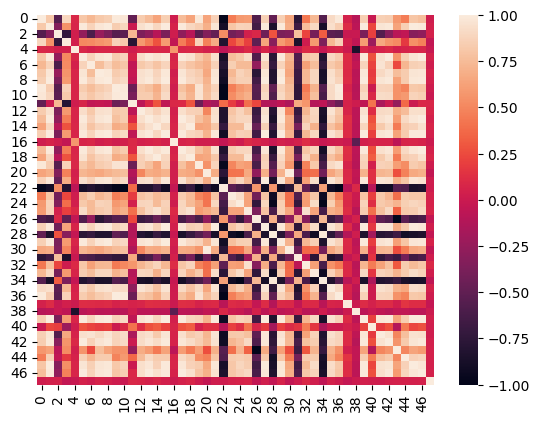

In [9]:

def remove_outliers_iqr(df, column, threshold=1.5):
    # Separate the label column from the features
    X = df.drop(column, axis=1)
    y = df[column]

    q1 = X.quantile(0.25)
    q3 = X.quantile(0.75)
    iqr = q3 - q1
    lower_threshold = q1 - threshold * iqr
    upper_threshold = q3 + threshold * iqr
    
    # Create a mask to identify outliers in each column
    outlier_mask = (X < lower_threshold) | (X > upper_threshold)
    
    # Remove outliers by replacing with NaN or dropping the rows
    X_no_outliers = X.mask(outlier_mask)
    y_no_outliers = y.mask(outlier_mask.any(axis=1))
    
    # Concatenate the features and label back together
    df_no_outliers = pd.concat([X_no_outliers, y_no_outliers], axis=1)

    return df_no_outliers


# Cleaning and normalizing the training and the target dataframe (i.e., df and df_target)
# so that AVERAGE, HEALTHY, and UNHEALTHY labels become [0, ]
df = remove_outliers_iqr(df, 'HEALTH_STA')
df = df[df['HEALTH_STA'].notna()]

le = preprocessing.LabelEncoder()
le.fit(df['HEALTH_STA'])
print('DF TARGET HEALTH CLASSES:', list(le.classes_))
df['HEALTH_STA'] = le.transform(df['HEALTH_STA'])

# loading the dataframe for the next date
de_target = remove_outliers_iqr(df_target, 'HEALTH_STA')
df_target = df_target[df_target['HEALTH_STA'].notna()]
le = preprocessing.LabelEncoder()
le.fit(df_target['HEALTH_STA'])
print('DF TARGET HEALTH CLASSES:', list(le.classes_))
df_target['HEALTH_STA'] = le.transform(df_target['HEALTH_STA'])

## Feature & Target Selection for the training dataframe (df)
X = df[[col for col in df.columns]]
X = X.drop(df.columns[0], axis=1) # Droping the first dataframe's column (with IDs)
X = X.drop('HEALTH_STA', axis=1) # Droping the label column from the dataframe
# X = X.drop('date', axis=1)
y = df['HEALTH_STA']
labels = y.unique()

# Removing inf values
X.replace([np.inf, -np.inf], np.nan, inplace=True)
mean_values = X.mean(axis=0)
X.fillna(mean_values, inplace=True)

# Putting the pixels and vegetation indices values into a scale from 0 to 1
min_max_scaler = preprocessing.MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(X)
X = pd.DataFrame(x_scaled)

X = X.astype(float)

#from imblearn.over_sampling import RandomOverSampler

# X_train and y_train are your feature matrix and target labels respectively

print('Unbalanced dataset for training:')
class_counts = np.bincount(y)
print(class_counts)

#majority_class_size = np.max(class_counts)
#sampling_strategy = {i: majority_class_size*1 for i in range(len(class_counts)) if class_counts[i] < majority_class_size}
# create an instance of the RandomOverSampler class
#ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)

#X_resampled, y_resampled = ros.fit_resample(X, y)

# Split the train and test sets into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Split the train and test sets into train and test sets again
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_next_date = df_target[[col for col in df_target.columns]]
X_next_date = X_next_date.drop('HEALTH_STA', axis=1)
# X_next_date = X_next_date.drop('date', axis=1)
X_next_date = X_next_date.drop(X_next_date.columns[0], axis=1) # Droping the first dataframe's column (with IDs)
y_next_date = df_target['HEALTH_STA']
y_next_date = y_next_date.dropna()

X_next_date.replace([np.inf, -np.inf], np.nan, inplace=True)
next_date_mean_values = X_next_date.mean(axis=0)
X_next_date.fillna(next_date_mean_values, inplace=True)

min_max_scaler = preprocessing.MinMaxScaler()
x_next_date_scaled = min_max_scaler.fit_transform(X_next_date)
X_next_date = pd.DataFrame(x_next_date_scaled)

X_next_date = X_next_date.astype(float)

class_counts = np.bincount(y_next_date)

#print('Balanced dataset for training (after oversampling):')
#counts = np.bincount(y_train)
#print(counts)

from imblearn.over_sampling import RandomOverSampler

# X_train and y_train are your feature matrix and target labels respectively
#majority_class_size = np.max(class_counts)
#sampling_strategy = {i: majority_class_size*1 for i in range(len(class_counts)) if class_counts[i] < majority_class_size}

# create an instance of the RandomOverSampler class
#ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)

#X_next_date_resampled, y_next_date_resampled = ros.fit_resample(X_next_date, y_next_date)

# Split the train and test sets into train and test sets
X_next_date_train, X_next_date_test, y_next_date_train, y_next_date_test = train_test_split(X_next_date, y_next_date, test_size=0.3, random_state=42)

class_counts = np.bincount(y_next_date_test)
print('Splitted unbalanced dataset for testing with the last date:')
print(class_counts)

# preview train & test sets
print('Train Set:', X_train.shape, y_train.shape)
print('Next Date Test Set:', X_next_date_test.shape, y_next_date_test.shape)

# build, train, & predict model
model = SVC(kernel='rbf', C=0.00001, gamma='auto', decision_function_shape='ovr', break_ties=True, random_state=42)
model.fit(X_train, y_train)
y_pred_svc = model.predict(X_next_date_test)

# evaluate results
print('##### SVC Metrics:')
print('MAE:', mean_absolute_error(y_next_date_test, y_pred_svc))
print('MSE:', mean_squared_error(y_next_date_test, y_pred_svc))
print('R2 Score:', r2_score(y_next_date_test, y_pred_svc))
print('F1-SCORE: ', f1_score(y_next_date_test, y_pred_svc, average='micro'))
print('TEST ACCURACY SCORE:', accuracy_score(y_next_date_test, y_pred_svc))

# Calculate accuracy per label
label_accuracy = precision_recall_fscore_support(y_next_date_test, y_pred_svc, average=None)
# The 'average=None' argument returns precision, recall, and F1-score for each label separately

# Print the accuracy per label
for label, accuracy in zip(labels, label_accuracy[0]):
    print(f"Label {label}: Test Accuracy = {accuracy}")

#y_pred_svc_val = y_pred = model.predict(X_next_date_test)
#print('VALIDATION ACCURACY SCORE:', accuracy_score(y_next_date_test, y_pred))

# Calculate accuracy per label
#label_accuracy = precision_recall_fscore_support(y_val, y_pred, average=None)
# The 'average=None' argument returns precision, recall, and F1-score for each label separately

# Print the accuracy per label
#for label, accuracy in zip(labels, label_accuracy[0]):
#    print(f"Label {label}: Validation Accuracy = {accuracy}")

# Concatenating X and y to check the correlation values
combined_df = pd.concat([X, y], axis=1)
correlation_matrix = combined_df.corr()

import seaborn as sns
sns.heatmap(correlation_matrix)


# RANDOM FOREST MODEL:

In [10]:

import numpy as np

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
param_grid = { 
    'n_estimators': [100, 200, 500],
    'max_features': [5, 'sqrt', 'log2'],
    'max_depth' : [4,5,6,7,8],
    'criterion' :['entropy', 'gini']
}

from scipy.stats import uniform

print('##### Random Forest Classifier')
rfc = RandomForestClassifier(random_state=42)
CV_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=10)

# fit
CV_rfc.fit(X_train, y_train)
print('Best Params Grid Search:')
print(CV_rfc.best_params_)

# Instantiate RandomizedSearchCV model
rs_model = RandomizedSearchCV(RandomForestClassifier(n_jobs=-1, random_state=42),
                               param_distributions=param_grid,
                               n_iter=10,
                               cv=10,
                               verbose=True)
rs_model.fit(X_train, y_train)
print('Best Params RandomizedSearch (RF):')
print(rs_model.best_params_)
best_params = rs_model.best_params_

print('Metrics (RFO)')
rfc_best = RandomForestClassifier(**best_params)
rfc_best.fit(X_train, y_train)
y_pred_rfc = rfc_best.predict(X_next_date_test)

print('MAE:', mean_absolute_error(y_next_date_test, y_pred_rfc))
print('MSE:', mean_squared_error(y_next_date_test, y_pred_rfc))
print('R2 Score:', r2_score(y_next_date_test, y_pred_rfc))
print('F1-SCORE: ', f1_score(y_next_date_test, y_pred_rfc, average='micro'))
print('TEST ACCURACY SCORE:', accuracy_score(y_next_date_test, y_pred_rfc))

# Calculate accuracy per label
label_accuracy = precision_recall_fscore_support(y_next_date_test, y_pred_rfc, average=None)
# The 'average=None' argument returns precision, recall, and F1-score for each label separately

# Print the accuracy per label
for label, accuracy in zip(labels, label_accuracy[0]):
    print(f"Label {label}: Test Accuracy = {accuracy}")

#y_pred_rfc_val = rfc_best.predict(X_next_date_test)
#print('VALIDATION ACCURACY SCORE:', accuracy_score(y_next_date_test, y_pred_rfc_val))

# Calculate accuracy per label
#label_accuracy = precision_recall_fscore_support(y_next_date_test, y_pred_rfc_val, average=None)
# The 'average=None' argument returns precision, recall, and F1-score for each label separately

## Print the accuracy per label
#for label, accuracy in zip(labels, label_accuracy[0]):
#    print(f"Label {label}: Validation Accuracy = {accuracy}")



##### Random Forest Classifier
Best Params Grid Search:
{'criterion': 'gini', 'max_depth': 5, 'max_features': 5, 'n_estimators': 100}
Fitting 10 folds for each of 10 candidates, totalling 100 fits
Best Params RandomizedSearch (RF):
{'n_estimators': 200, 'max_features': 'log2', 'max_depth': 6, 'criterion': 'entropy'}
Metrics (RFO)
MAE: 0.3466666666666667
MSE: 0.64
R2 Score: -0.3215859030837003
F1-SCORE:  0.8000000000000002
TEST ACCURACY SCORE: 0.8
Label 0: Test Accuracy = 0.8108108108108109
Label 2: Test Accuracy = 0.0
Label 1: Test Accuracy = 0.0


c:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\myenv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Performing a CNN classification task:

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from keras.wrappers.scikit_learn import KerasClassifier


# Build the CNN model
def create_cnn_model():
    cnn_model = Sequential()
    cnn_model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
    cnn_model.add(Dense(64, activation='relu'))
    cnn_model.add(Dense(1, activation='sigmoid'))
    
    # Compile the model
    cnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return cnn_model

cnn_model = KerasClassifier(build_fn=create_cnn_model, epochs=100, batch_size=32, verbose=0)

# Train the model
cnn_model.fit(X_train, y_train, epochs=100, batch_size=32)

y_pred_cnn = cnn_model.predict(X_next_date_test)

# evaluate results
print('##### CNN Metrics:')
print('MAE:', mean_absolute_error(y_next_date_test, y_pred_cnn))
print('MSE:', mean_squared_error(y_next_date_test, y_pred_cnn))
print('R2 Score:', r2_score(y_next_date_test, y_pred_cnn))
y_pred_cnn_labels = np.argmax(y_pred_cnn, axis=1)
print('F1-SCORE: ', f1_score(y_next_date_test, y_pred_cnn_labels, average='weighted'))
print('TEST ACCURACY SCORE:', accuracy_score(y_next_date_test, y_pred_cnn_labels))

# Calculate accuracy per label
label_accuracy = precision_recall_fscore_support(y_next_date_test, y_pred_cnn_labels, average=None)
# The 'average=None' argument returns precision, recall, and F1-score for each label separately

# Print the accuracy per label
for label, accuracy in zip(labels, label_accuracy[0]):
    print(f"Label {label}: Test Accuracy = {accuracy}")

C:\Users\flopes1\AppData\Local\Temp\ipykernel_23836\2042341040.py:21: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  cnn_model = KerasClassifier(build_fn=create_cnn_model, epochs=100, batch_size=32, verbose=0)


3/3 [==============================] - 0s 3ms/step
##### CNN Metrics:
MAE: 0.41333333333333333
MSE: 0.68
R2 Score: -0.40418502202643136
F1-SCORE:  0.7296078431372549
TEST ACCURACY SCORE: 0.8133333333333334
Label 0: Test Accuracy = 0.8133333333333334
Label 2: Test Accuracy = 0.0
Label 1: Test Accuracy = 0.0


c:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\myenv\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [12]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Define the number of folds (k)
k = 10

# Create an instance of the k-fold cross-validator
kfold = KFold(n_splits=k, shuffle=True, random_state=42)

# Perform k-fold cross-validation
scores = cross_val_score(model, X_next_date_test, y_next_date_test, cv=kfold)
rfc_scores = cross_val_score(rfc_best, X_next_date_test, y_next_date_test, cv=kfold)
cnn_scores = cross_val_score(cnn_model, X_next_date_test, y_next_date_test, cv=kfold)

# Print the cross-validation scores
print('\n SVC:')
print("Cross-validation scores:", scores)
print("Average score:", scores.mean())

print('\n RFC:')
print("Cross-validation scores:", rfc_scores)
print("Average score:", rfc_scores.mean())

print('\n CNN:')
print("Cross-validation scores:", cnn_scores)
print("Average score:", cnn_scores.mean())


 SVC:
Cross-validation scores: [0.875      0.875      0.625      0.875      0.75       1.
 0.85714286 0.57142857 0.85714286 0.85714286]
Average score: 0.8142857142857143

 RFC:
Cross-validation scores: [0.875      0.625      0.625      0.875      0.75       1.
 0.85714286 0.57142857 0.85714286 0.71428571]
Average score: 0.775

 CNN:
Cross-validation scores: [0.75       0.375      0.625      0.75       0.75       0.85714287
 0.5714286  0.71428573 0.71428573 0.5714286 ]
Average score: 0.667857152223587


(75,)
(75,)
(75,)
(75,)
(75,)
(75, 1)


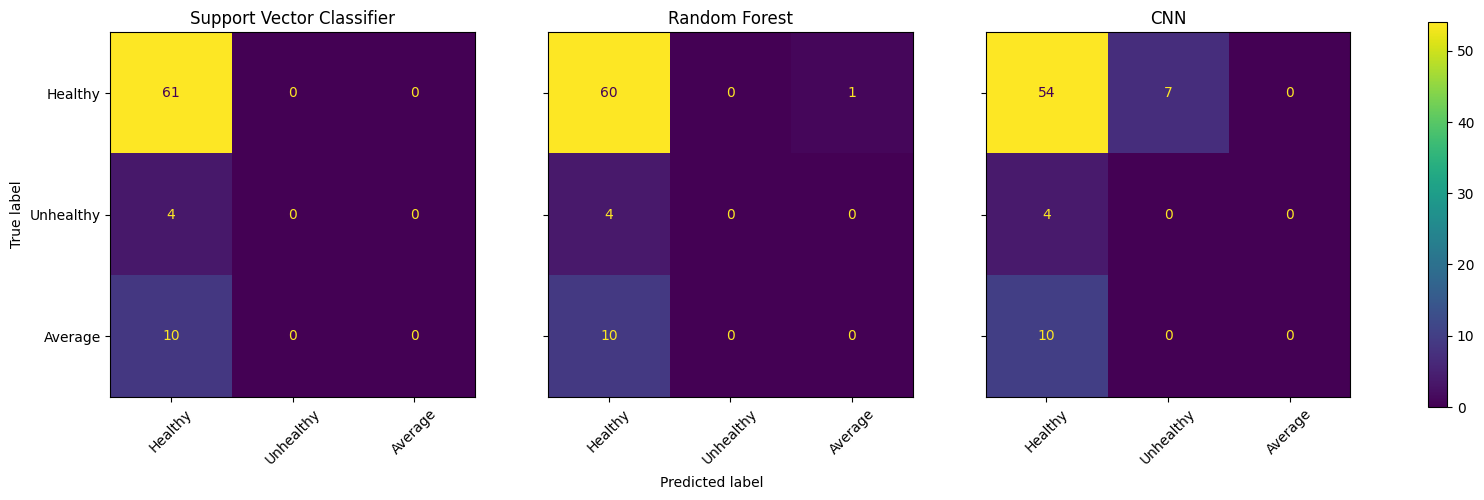

In [24]:
# Plot the confusion matrix for the SVM model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = ['Healthy', 'Unhealthy', 'Average']
f, axes = plt.subplots(1, 3, figsize=(20, 5), sharey='row')

print(y_next_date_test.shape)
print(y_pred_svc.shape)
cm = confusion_matrix(y_next_date_test, y_pred_svc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], xticks_rotation=45)
disp.ax_.set_title("Support Vector Classifier")
disp.im_.colorbar.remove()
disp.ax_.set_xlabel('')


# Plot the confusion matrix for the Random Forest model
print(y_next_date_test.shape)
print(y_pred_rfc.shape)
cm = confusion_matrix(y_next_date_test, y_pred_rfc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[1], xticks_rotation=45)
disp.ax_.set_title("Random Forest")
disp.im_.colorbar.remove()
disp.ax_.set_xlabel('')
disp.ax_.set_ylabel('')


print(y_next_date_test.shape)
print(y_pred_cnn.shape)
cm = confusion_matrix(y_next_date_test, y_pred_cnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[2], xticks_rotation=45)
disp.ax_.set_title("CNN")
disp.im_.colorbar.remove()
disp.ax_.set_xlabel('')
disp.ax_.set_ylabel('')

f.text(0.4, -0.05, 'Predicted label', ha='left')
plt.subplots_adjust(wspace=0.20, hspace=0.1)

f.colorbar(disp.im_, ax=axes)
plt.show()

Columns


C:\Users\flopes1\AppData\Local\Temp\ipykernel_23836\2360755085.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(sorted_labels, fontsize=14)


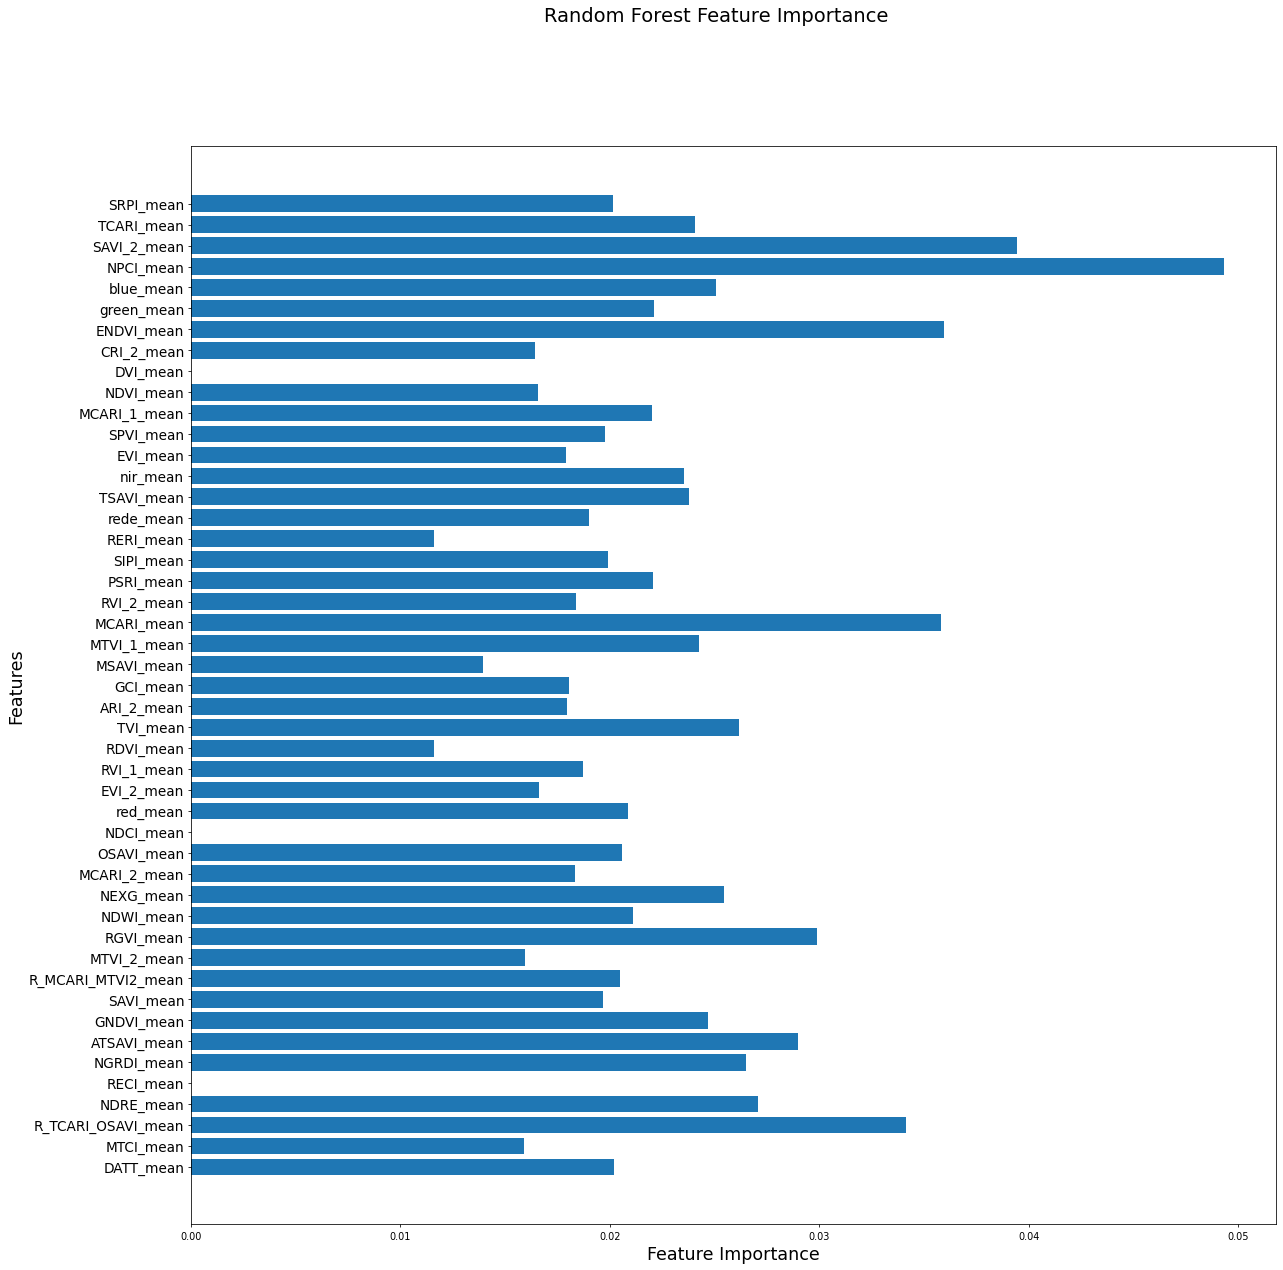

<Figure size 2000x500 with 0 Axes>

{'importances_mean': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'importances_std': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'importances': array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
 

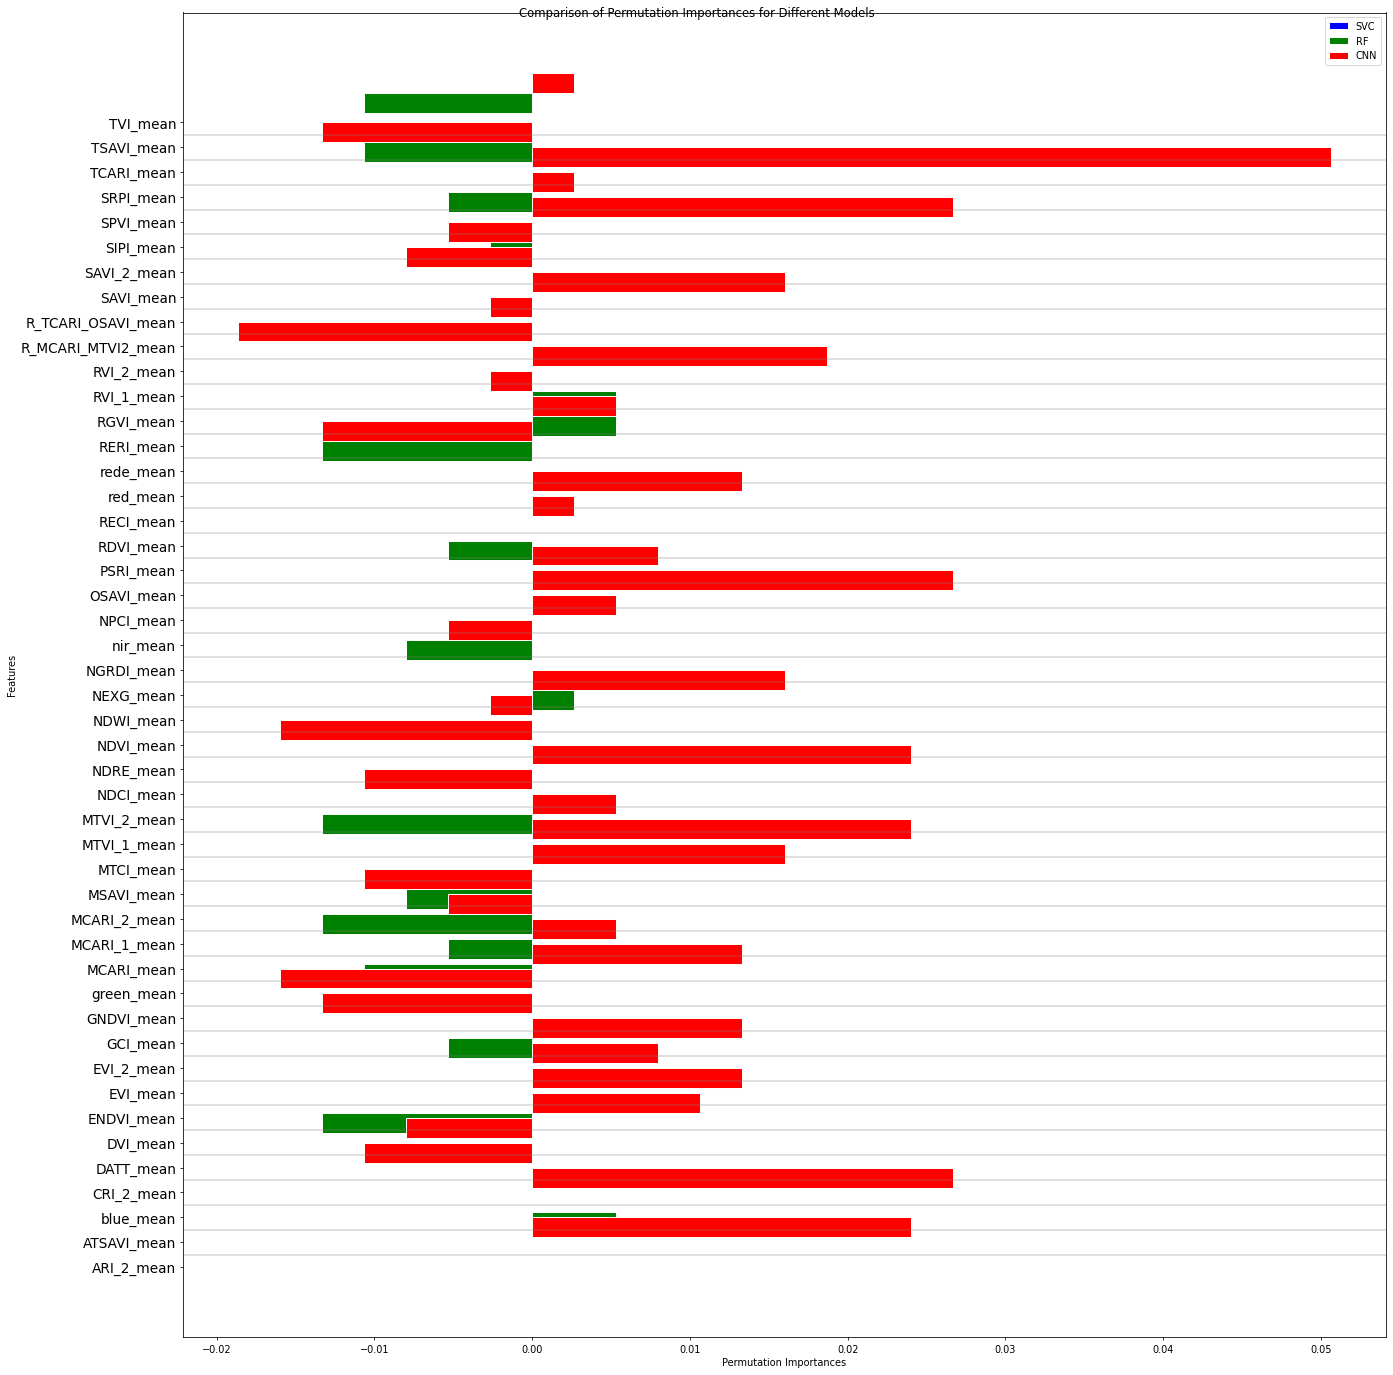

In [81]:
from sklearn.inspection import permutation_importance

fig, ax = plt.subplots(1, 1, figsize=(20, 20), dpi=70)
list_feature_importance_rfc = list(rfc_best.feature_importances_)


fig.suptitle('Random Forest Feature Importance', fontsize = 20)
ax.set_ylabel('Features',  fontsize = 18)
ax.set_xlabel('Feature Importance', fontsize = 18)
plt.figure(figsize=(20, 5))

print('Columns')
X.columns = [col for col in df.columns if col != 'HEALTH_STA' and col != 'Unnamed: 0']
ax.barh(y=X.columns, width=list_feature_importance_rfc)
importance_dict = dict(zip(X.columns, list_feature_importance_rfc))
sorted_labels = sorted(importance_dict, key=lambda k: importance_dict[k])
ax.set_yticklabels(sorted_labels, fontsize=14)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(1, 1, figsize=(20, 20), dpi=70)
perm_importance_svc = permutation_importance(model, X_next_date_test, y_next_date_test, random_state=42)
print(perm_importance_svc)
perm_importance_rfc = permutation_importance(rfc_best, X_next_date_test, y_next_date_test, random_state=42)
perm_importance_cnn = permutation_importance(cnn_model, X_next_date_test, y_next_date_test, random_state=42)

features = [col for col in df.columns if col != 'HEALTH_STA' and col != 'Unnamed: 0']

# Set the bar width
bar_height = 0.8

# Set the positions of the bars on the x-axis
r1 = np.arange(len(features))
r2 = [y + bar_height for y in r1]
r3 = [y + bar_height for y in r2]

# Add horizontal lines to group features
for i in range(1, len(features)):
    ax.axhline(i - 0.5, color='gray', linewidth=0.5)

# Create the bar chart
rects1 = ax.barh(r1, perm_importance_svc.importances_mean, color='b', edgecolor='white', tick_label=features, label='SVC')
rects2 = ax.barh(r2, perm_importance_rfc.importances_mean, color='g', edgecolor='white', tick_label=features, label='RF')
rects3 = ax.barh(r3, perm_importance_cnn.importances_mean, color='r', edgecolor='white', tick_label=features, label='CNN')



# Add x-axis labels, y-axis label, and title
ax.set_ylabel('Features')
ax.set_xlabel('Permutation Importances')
fig.suptitle('Comparison of Permutation Importances for Different Models')
print(features)
# Add x-axis tick labels
ax.set_yticks(r1)
ax.set_yticklabels(features, fontsize=14)
# Adjust spacing to avoid overlapping tick labels
plt.tight_layout()

# Add a legend
plt.legend()

# Display the plot
plt.show()

#fig, ax = plt.subplots(1, 1, figsize=(10, 10))

#print(X.columns)

#fig.suptitle('Permutation Importance', fontsize = 20)
#plt.barh(y=X.columns, width=perm_importance_svc.importances_mean)
#importance_dict = dict(zip(X.columns, perm_importance_svc))
#print(importance_dict)
#sorted_labels = sorted(importance_dict, key=lambda k: importance_dict[k])
#print(sorted_labels)
#ax.set_yticklabels(sorted_labels, fontsize=14)
#plt.tight_layout()
#plt.show()



# Test the dataset for unhealthy
# Test using other dates as input

['ARI_2_mean', 'ATSAVI_mean', 'blue_mean', 'CRI_2_mean', 'DATT_mean', 'DVI_mean', 'ENDVI_mean', 'EVI_mean', 'EVI_2_mean', 'GCI_mean', 'GNDVI_mean', 'green_mean', 'MCARI_mean', 'MCARI_1_mean', 'MCARI_2_mean', 'MSAVI_mean', 'MTCI_mean', 'MTVI_1_mean', 'MTVI_2_mean', 'NDCI_mean', 'NDRE_mean', 'NDVI_mean', 'NDWI_mean', 'NEXG_mean', 'NGRDI_mean', 'nir_mean', 'NPCI_mean', 'OSAVI_mean', 'PSRI_mean', 'RDVI_mean', 'RECI_mean', 'red_mean', 'rede_mean', 'RERI_mean', 'RGVI_mean', 'RVI_1_mean', 'RVI_2_mean', 'R_MCARI_MTVI2_mean', 'R_TCARI_OSAVI_mean', 'SAVI_mean', 'SAVI_2_mean', 'SIPI_mean', 'SPVI_mean', 'SRPI_mean', 'TCARI_mean', 'TSAVI_mean', 'TVI_mean']


C:\Users\flopes1\AppData\Local\Temp\ipykernel_23836\518739081.py:18: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(features)


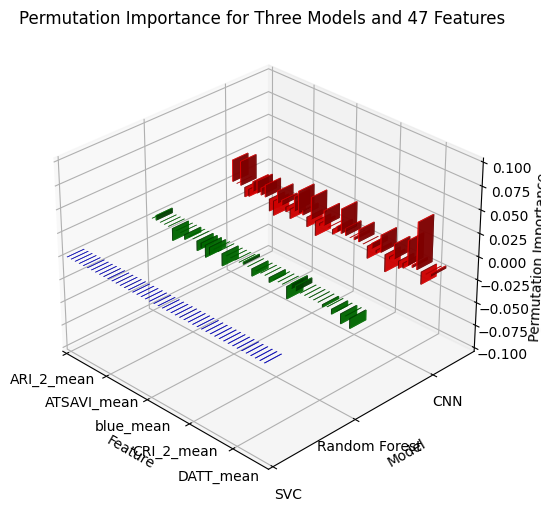

In [115]:
# Create the figure and axis
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111, projection='3d')

# Define the positions for the bars
r1 = np.arange(47)
r2 = r1 + 0.25
r3 = r1 + 0.5

# Create the 3D bars for each model
ax.bar3d(r1, np.zeros_like(r1), np.zeros_like(r1), 0.2, 0.2, perm_importance_svc.importances_mean, color='b', alpha=0.8)
ax.bar3d(r2, np.ones_like(r2), np.zeros_like(r2), 0.2, 0.2, perm_importance_rfc.importances_mean, color='g', alpha=0.8)
ax.bar3d(r3, 2*np.ones_like(r3), np.zeros_like(r3), 0.2, 0.2, perm_importance_cnn.importances_mean, color='r', alpha=0.8)

# Set the tick labels and limits
ax.set_yticks(np.arange(3))
print(features)
ax.set_xticklabels(features)
models = ['SVC', 'Random Forest', 'CNN']
ax.set_yticklabels(models)
ax.set_xlim(0, 47)
ax.set_ylim(0, 2.5)
ax.set_zlim(-0.1, 0.1)  # Adjust the z-axis limits as needed

# Set labels and title
ax.set_xlabel('Feature')
ax.set_ylabel('Model')
ax.set_zlabel('Permutation Importance')
ax.set_title('Permutation Importance for Three Models and 47 Features')

# Adjust the view angle
ax.view_init(elev=30, azim=-45)

# Show the plot
plt.show()

In [ ]:
# Extract the dates column and remove duplicates
dates = df['date'].unique()
print(dates)
# Set the dates column as the index
df.set_index('date', inplace=True)
